# Bike analysis

In [7]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import os
import sys


In [8]:
trip_data = pd.read_csv("C:\\Users\\Minamsj\\FOMOsim\\policies\\sjovik_sund\\simulation_results\\Newest results\\sjovik_sund_alphas_0812252309_TD_seed_1_alpha01-05_fullweek_0.300_results_trip_requests_seed_1.csv")
    
#print account of trips per bike and their assosicated criticality for each trip
bike_trip_counts = trip_data['Bike ID'].value_counts()
print("Trip counts per bike:")
print(bike_trip_counts)
bike_criticality = trip_data.groupby('Bike ID')['Bike Criticality']
print("\nAverage criticality per bike:")
print(bike_criticality)

Trip counts per bike:
Bike ID
B656    34
B705    32
B677    32
B432    32
B256    32
        ..
B306     2
B178     2
B668     2
B766     1
B401     1
Name: count, Length: 763, dtype: int64

Average criticality per bike:


In [9]:
# Check what columns are in the trip data
print("Available columns in trip_data:")
print(trip_data.columns.tolist())
print("\nFirst few rows:")
print(trip_data.head())

Available columns in trip_data:
['Seed', 'Alpha', 'Day', 'Hour', 'Minute', 'Time (minutes)', 'Station ID', 'Success', 'Failure Reason', 'Did Roam', 'Arrival Station ID', 'Travel Time (minutes)', 'Bike ID', 'Bike Criticality']

First few rows:
   Seed  Alpha  Day  Hour  Minute  Time (minutes) Station ID  Success  \
0     1    0.3    0     7       0             420         S2     True   
1     1    0.3    0     7       0             420        S51     True   
2     1    0.3    0     7       1             421        S64     True   
3     1    0.3    0     7       2             422        S22     True   
4     1    0.3    0     7       2             422        S28     True   

  Failure Reason  Did Roam Arrival Station ID  Travel Time (minutes) Bike ID  \
0            NaN     False                 S7                   9.42     B17   
1            NaN     False                S52                   2.08    B572   
2            NaN     False                S54                  16.25    B737  

In [ ]:
colors = [
    ("Pale Fern", "#D9E5D6"),
    ("Sage Green", "#84A579"),
    ("Dark Spruce", "#344E41"),
    ("Warm Red", "#D1495B"),
    ("Ochre Gold", "#EDAE49"),
    ("Blue Accent", "#526ECA"),  
    ("Mist Grey", "#E6E6E6"),
]


Trip data for Bike ID B656:
       Day  Hour  Minute  Time (minutes) Station ID Arrival Station ID  \
154      0     7      58             478        S58                S60   
230      0     8      35             515        S60                S65   
895      0    12      25             745        S65                S48   
1699     0    14      56             896        S48                S21   
2353     0    18      11            1091        S21                S54   
2464     0    18      46            1126        S54                S30   
2784     1     5       5            1745        S30                S35   
2881     1     5      34            1774        S35                S61   
2917     1     5      42            1782        S61                S62   
3293     1     7      55            1915        S62                S55   
3825     1    11      30            2130        S55                S35   
3845     1    11      36            2136        S42                S42   
3896     

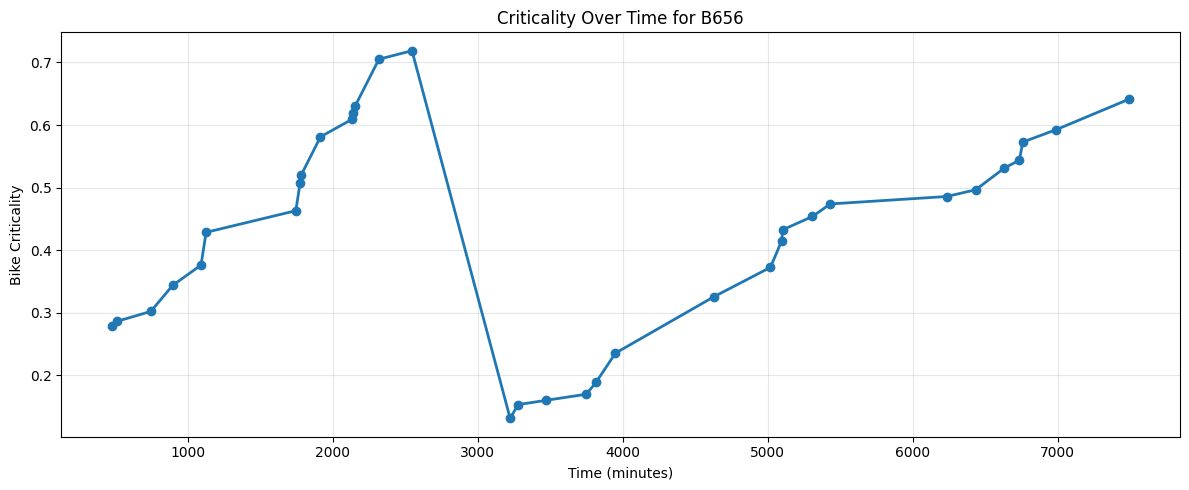


Criticality Statistics for B656:
Mean: 0.4336
Min: 0.1310
Max: 0.7188
Std: 0.1668


In [ ]:
# Analyze how criticality changed over time for a specific bike
bike_id = "B656"
bike_data = trip_data[trip_data['Bike ID'] == bike_id].copy()
bike_data = bike_data.sort_values('Time (minutes)')

print(f"\nTrip data for Bike ID {bike_id}:")
print(bike_data[['Day', 'Hour', 'Minute', 'Time (minutes)', 'Station ID', 'Arrival Station ID', 'Bike Criticality']])

# Plot criticality over time
plt.figure(figsize=(12, 5))
plt.plot(bike_data['Time (minutes)'], bike_data['Bike Criticality'], marker='o', linestyle='-', linewidth=2, color=colors[5][1])
plt.xlabel('Time (minutes)')
plt.ylabel('Bike Criticality')
plt.title(f'Criticality Over Time for {bike_id}')
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

print(f"\nCriticality Statistics for {bike_id}:")
print(f"Mean: {bike_data['Bike Criticality'].mean():.4f}")
print(f"Min: {bike_data['Bike Criticality'].min():.4f}")
print(f"Max: {bike_data['Bike Criticality'].max():.4f}")
print(f"Std: {bike_data['Bike Criticality'].std():.4f}")

Bikes with most criticality variation (top 10):
              std  count      mean
Bike ID                           
B535     0.377258      4  0.653375
B41      0.366303     11  0.476118
B79      0.358803     19  0.433189
B612     0.342686     16  0.495200
B451     0.339403     17  0.491759
B150     0.337413     13  0.407138
B420     0.330819     21  0.439148
B118     0.315312     19  0.509347
B64      0.314899     16  0.539713
B315     0.307979     12  0.453650


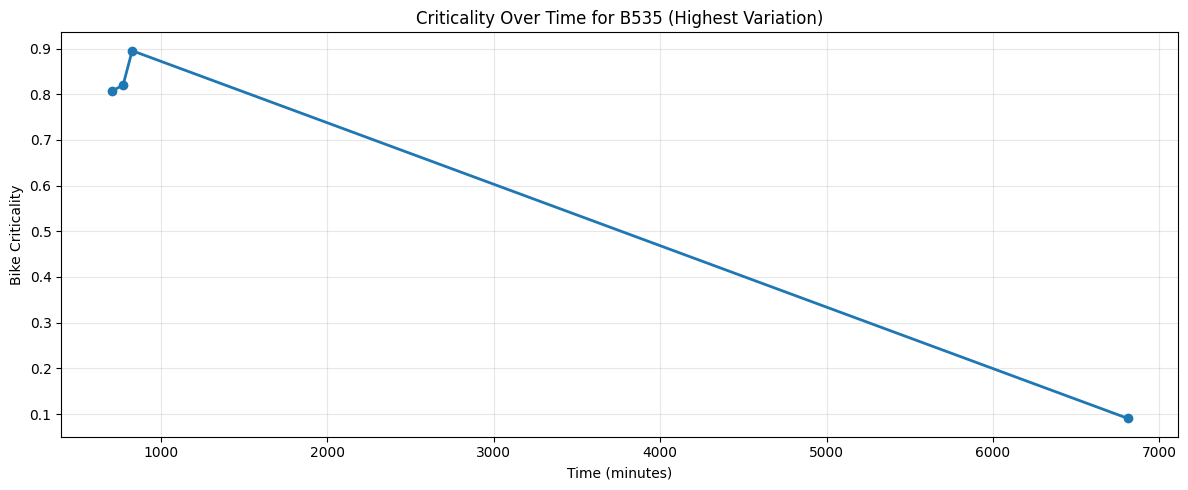

In [ ]:
# Find bikes with varying criticality
bike_criticality_variance = trip_data.groupby('Bike ID')['Bike Criticality'].agg(['std', 'count', 'mean'])
bike_criticality_variance = bike_criticality_variance[bike_criticality_variance['count'] > 1]
bike_criticality_variance = bike_criticality_variance.sort_values('std', ascending=False)

print("Bikes with most criticality variation (top 10):")
print(bike_criticality_variance.head(10))

# Plot a bike with high variation
if len(bike_criticality_variance) > 0 and bike_criticality_variance.iloc[0]['std'] > 0:
    most_varying_bike = bike_criticality_variance.index[0]
    varying_bike_data = trip_data[trip_data['Bike ID'] == most_varying_bike].copy()
    varying_bike_data = varying_bike_data.sort_values('Time (minutes)')
    
    plt.figure(figsize=(12, 5))
    plt.plot(varying_bike_data['Time (minutes)'], varying_bike_data['Bike Criticality'], marker='o', linestyle='-', linewidth=2)
    plt.xlabel('Time (minutes)')
    plt.ylabel('Bike Criticality')
    plt.title(f'Criticality Over Time for {most_varying_bike} (Highest Variation)')
    plt.grid(True, alpha=0.3)
    plt.tight_layout()
    plt.show()
else:
    print("\nNo bikes show criticality variation - all criticalities appear to be static.")

Bikes with at least 2 direction changes (e.g., up->down->up pattern):
Found 421 bikes with this pattern

1. B640: 5 changes, 20 trips, range: 0.1722 - 0.6672
   Criticality sequence: ['0.6258', '0.6672', '0.1722', '0.1985', '0.2126', '0.2229', '0.2308', '0.2485', '0.2905', '0.3015', '0.3147', '0.3433', '0.3477', '0.3660', '0.3863', '0.4012', '0.2500', '0.2589', '0.2658', '0.2330']
2. B161: 5 changes, 18 trips, range: 0.1106 - 0.8698
   Criticality sequence: ['0.8698', '0.7929', '0.8180', '0.8254', '0.8618', '0.1106', '0.1133', '0.1355', '0.2598', '0.3020', '0.4132', '0.4215', '0.4286', '0.4482', '0.4593', '0.4777', '0.4502', '0.4664']
3. B587: 5 changes, 20 trips, range: 0.2708 - 0.6799
   Criticality sequence: ['0.6629', '0.6641', '0.6799', '0.3228', '0.3343', '0.5217', '0.2708', '0.2858', '0.3524', '0.4069', '0.4197', '0.4743', '0.4873', '0.5049', '0.5220', '0.5411', '0.6206', '0.6339', '0.6400', '0.4258']
4. B30: 5 changes, 19 trips, range: 0.2452 - 0.5521
   Criticality sequence: [

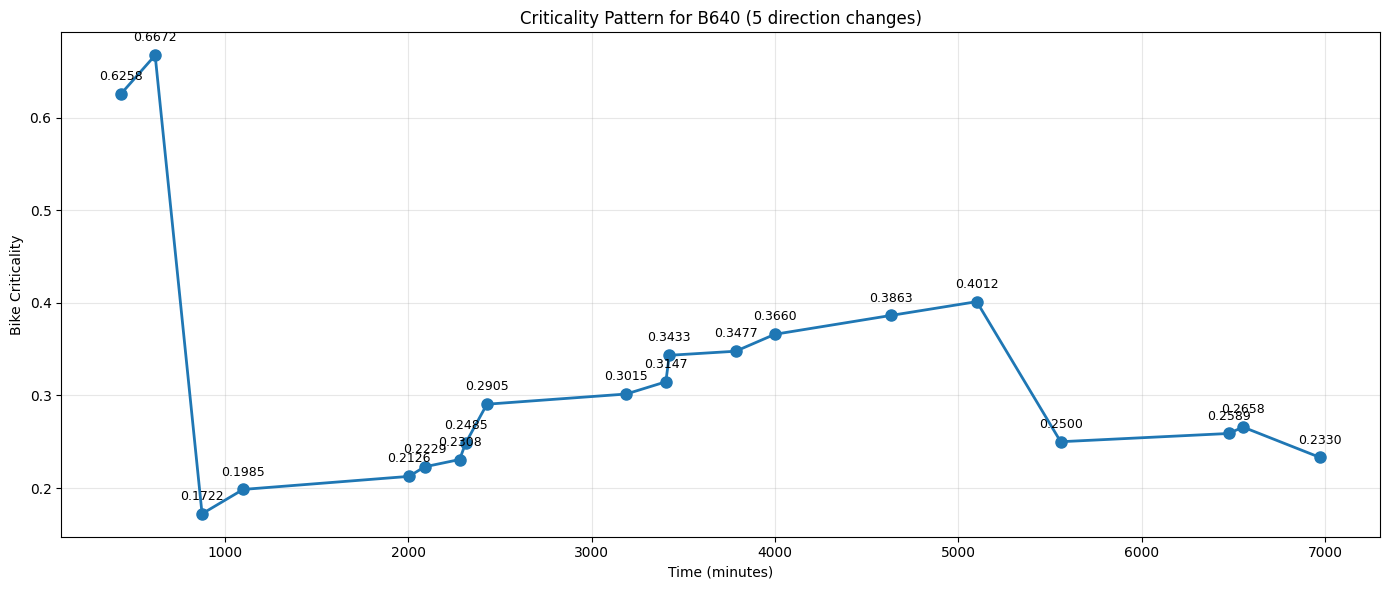

In [12]:
# Find bikes with direction changes in criticality (up -> down -> up pattern)
def count_direction_changes(criticality_values):
    """Count how many times criticality changes direction (increasing to decreasing or vice versa)"""
    if len(criticality_values) < 3:
        return 0
    
    changes = 0
    prev_direction = None
    
    for i in range(1, len(criticality_values)):
        diff = criticality_values[i] - criticality_values[i-1]
        
        if diff > 0.0001:  # Going up (with small tolerance for floating point)
            current_direction = 'up'
        elif diff < -0.0001:  # Going down
            current_direction = 'down'
        else:  # No change
            continue
            
        if prev_direction is not None and current_direction != prev_direction:
            changes += 1
            
        prev_direction = current_direction
    
    return changes

# Analyze direction changes for each bike
bike_direction_changes = []

for bike_id in trip_data['Bike ID'].unique():
    bike_trips = trip_data[trip_data['Bike ID'] == bike_id].sort_values('Time (minutes)')
    criticalities = bike_trips['Bike Criticality'].values
    
    if len(criticalities) >= 3:
        num_changes = count_direction_changes(criticalities)
        if num_changes >= 2:  # At least 2 direction changes (e.g., up->down->up)
            bike_direction_changes.append({
                'Bike ID': bike_id,
                'Direction Changes': num_changes,
                'Num Trips': len(criticalities),
                'Criticality Range': f"{criticalities.min():.4f} - {criticalities.max():.4f}",
                'Criticalities': criticalities.tolist()
            })

# Sort by number of direction changes
bike_direction_changes.sort(key=lambda x: x['Direction Changes'], reverse=True)

print(f"Bikes with at least 2 direction changes (e.g., up->down->up pattern):")
print(f"Found {len(bike_direction_changes)} bikes with this pattern\n")

if len(bike_direction_changes) > 0:
    for i, bike_info in enumerate(bike_direction_changes[:10]):  # Show top 10
        print(f"{i+1}. {bike_info['Bike ID']}: {bike_info['Direction Changes']} changes, "
              f"{bike_info['Num Trips']} trips, range: {bike_info['Criticality Range']}")
        print(f"   Criticality sequence: {[f'{c:.4f}' for c in bike_info['Criticalities']]}")
    
    # Plot the first bike with direction changes
    print(f"\nPlotting criticality pattern for {bike_direction_changes[0]['Bike ID']}:")
    
    bike_id = bike_direction_changes[0]['Bike ID']
    bike_trips = trip_data[trip_data['Bike ID'] == bike_id].sort_values('Time (minutes)')
    
    plt.figure(figsize=(14, 6))
    plt.plot(bike_trips['Time (minutes)'], bike_trips['Bike Criticality'], 
             marker='o', linestyle='-', linewidth=2, markersize=8)
    
    # Annotate each point with its value
    for idx, row in bike_trips.iterrows():
        plt.annotate(f'{row["Bike Criticality"]:.4f}', 
                    xy=(row['Time (minutes)'], row['Bike Criticality']),
                    xytext=(0, 10), textcoords='offset points', 
                    ha='center', fontsize=9)
    
    plt.xlabel('Time (minutes)')
    plt.ylabel('Bike Criticality')
    plt.title(f'Criticality Pattern for {bike_id} ({bike_direction_changes[0]["Direction Changes"]} direction changes)')
    plt.grid(True, alpha=0.3)
    plt.tight_layout()
    plt.show()
else:
    print("No bikes found with direction changes in criticality.")